
# Task 3 Demo: Jurisdiction-Aware AI Credit Scoring Governance Prototype

This notebook is a lightweight RegTech prototype for the Task 3 concept: a governance and compliance monitoring layer around an AI credit scoring model for a cross-border bank such as HSBC. It uses synthetic lending data because real cross-jurisdiction consumer lending datasets with sensitive governance attributes are limited and should not be casually reused for a class prototype.

The prototype demonstrates nine modules:

1. Generate a synthetic loan dataset
2. Train a simple credit scoring model
3. Output model performance: accuracy, AUC, confusion matrix
4. Calculate fairness metrics: approval disparity, FPR gap, FNR gap
5. Provide explainability: feature importance and rejection reasons
6. Simulate a monitoring period and detect model drift
7. Build a jurisdiction rule engine: United States vs European Union
8. Output a compliance report showing how the same metric triggers different jurisdictional results
9. Export tables and charts for PPT use



## Regulatory basis used in this prototype

The legal logic below is intentionally narrow and transparent. It does **not** claim that numeric thresholds are statutory rules. The thresholds are internal governance triggers used to operationalize real regulatory obligations. They are deliberately jurisdiction-specific so that the same metric can create different governance outcomes.

**United States**

- Equal Credit Opportunity Act (ECOA), 15 U.S.C. 1691 et seq., prohibits discrimination in credit transactions.
- Regulation B, 12 CFR Part 1002, implements ECOA and requires adverse action notices with specific reasons for denial.
- CFPB Circular 2022-03 states that ECOA and Regulation B do not allow creditors to avoid specific adverse action explanations merely because they use complex algorithms.
- CFPB Circular 2023-03 emphasizes that sample adverse action reasons are insufficient when they do not specifically and accurately describe the actual principal reasons.

**European Union**

- Regulation (EU) 2024/1689, the EU AI Act, classifies AI systems used to evaluate the creditworthiness of natural persons or establish credit scores as high-risk systems under Annex III, subject to limited exceptions.
- For high-risk AI systems, the AI Act includes requirements on risk management, data governance, technical documentation, record keeping/logging, transparency, human oversight, accuracy, robustness, cybersecurity, and post-market monitoring.

Sources: CFPB Circular 2022-03, CFPB Circular 2023-03, and EUR-Lex Regulation (EU) 2024/1689.


In [1]:

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
OUTPUT_DIR = Path.cwd()
print('Output directory:', OUTPUT_DIR)


Output directory: C:\Users\YL\Documents\Codex\2026-05-17\files-mentioned-by-the-user-assignment


## 1. Generate synthetic loan dataset

In [2]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def generate_loan_applicants(n=2500, seed=42, drift_month=0):
    """Generate synthetic loan applicants.

    drift_month > 0 simulates post-deployment changes in the applicant pool.
    The protected attribute is kept out of model features but used for governance testing.
    """
    local_rng = np.random.default_rng(seed + drift_month * 101)
    protected_group = local_rng.choice(['Majority', 'Minority'], size=n, p=[0.68, 0.32])
    jurisdiction = local_rng.choice(['US', 'EU'], size=n, p=[0.55, 0.45])
    age = np.clip(local_rng.normal(39, 11, n).round(), 21, 70)
    employment_years = np.clip(local_rng.gamma(3.0, 2.2, n), 0, 35)

    group_income_shift = np.where(protected_group == 'Minority', -4500, 2500)
    drift_income_shift = -650 * drift_month + np.where(protected_group == 'Minority', -550 * drift_month, 0)
    annual_income = np.clip(local_rng.normal(66000, 19000, n) + group_income_shift + drift_income_shift, 18000, 165000)

    credit_history_years = np.clip(local_rng.normal(8.0, 4.0, n) + np.where(protected_group == 'Minority', -0.9, 0.5), 0.5, 28)
    missed_payments = local_rng.poisson(np.clip(1.0 + np.where(protected_group == 'Minority', 0.35, 0) + 0.08 * drift_month, 0.1, 4), n)
    debt_to_income = np.clip(local_rng.normal(0.34, 0.12, n) + np.where(protected_group == 'Minority', 0.035, -0.01) + 0.01 * drift_month, 0.02, 0.85)
    loan_amount = np.clip(local_rng.normal(23000, 8500, n) + 0.10 * annual_income * local_rng.random(n), 3000, 85000)
    prior_default = local_rng.binomial(1, np.clip(0.05 + 0.025 * missed_payments + 0.01 * drift_month, 0.01, 0.45), n)
    product_type = local_rng.choice(['personal', 'auto', 'home_improvement'], size=n, p=[0.50, 0.30, 0.20])

    linear = (
        -1.2
        + 0.000026 * annual_income
        - 2.25 * debt_to_income
        + 0.105 * credit_history_years
        - 0.38 * missed_payments
        - 1.15 * prior_default
        - 0.000011 * loan_amount
        + 0.020 * employment_years
        + np.where(product_type == 'auto', 0.18, 0)
        + np.where(product_type == 'home_improvement', 0.08, 0)
    )
    repayment_probability = sigmoid(linear)
    repaid = local_rng.binomial(1, repayment_probability)

    df = pd.DataFrame({
        'applicant_id': [f'A{drift_month:02d}-{i:05d}' for i in range(n)],
        'monitoring_month': drift_month,
        'jurisdiction': jurisdiction,
        'protected_group': protected_group,
        'age': age.astype(int),
        'annual_income': annual_income.round(2),
        'employment_years': employment_years.round(2),
        'debt_to_income': debt_to_income.round(3),
        'credit_history_years': credit_history_years.round(2),
        'missed_payments_12m': missed_payments.astype(int),
        'prior_default': prior_default.astype(int),
        'loan_amount': loan_amount.round(2),
        'product_type': product_type,
        'actual_repaid': repaid.astype(int),
        'true_repayment_probability': repayment_probability.round(4),
    })
    return df

loan_df = generate_loan_applicants(n=2500, seed=RANDOM_SEED, drift_month=0)
loan_df.to_csv(OUTPUT_DIR / 'synthetic_loan_data.csv', index=False)
loan_df.head()


,applicant_id,monitoring_month,jurisdiction,protected_group,age,annual_income,employment_years,debt_to_income,credit_history_years,missed_payments_12m,prior_default,loan_amount,product_type,actual_repaid,true_repayment_probability
0,A00-00000,0,US,Minority,27,78727.67,4.99,0.462,4.61,3,1,25247.80,auto,0,0.1197
1,A00-00001,0,EU,Majority,33,86506.52,3.45,0.419,5.47,1,0,29587.36,personal,1,0.5111
2,A00-00002,0,EU,Minority,42,75219.35,4.44,0.288,5.16,1,1,10508.88,auto,0,0.3260
3,A00-00003,0,EU,Minority,32,77625.48,5.30,0.439,10.02,2,0,27295.46,auto,0,0.5271
4,A00-00004,0,US,Majority,36,64099.99,6.63,0.308,4.77,1,0,31530.93,personal,0,0.4208


## 2. Train a simple credit scoring model

In [3]:

feature_cols = [
    'age', 'annual_income', 'employment_years', 'debt_to_income',
    'credit_history_years', 'missed_payments_12m', 'prior_default',
    'loan_amount', 'product_type'
]
target_col = 'actual_repaid'

X = loan_df[feature_cols]
y = loan_df[target_col]
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, loan_df.index, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)

numeric_features = [c for c in feature_cols if c != 'product_type']
categorical_features = ['product_type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
])

model.fit(X_train, y_train)

APPROVAL_THRESHOLD = 0.55
loan_df['predicted_repayment_probability'] = model.predict_proba(loan_df[feature_cols])[:, 1]
loan_df['approved'] = (loan_df['predicted_repayment_probability'] >= APPROVAL_THRESHOLD).astype(int)
loan_df.to_csv(OUTPUT_DIR / 'synthetic_loan_data.csv', index=False)
print('Model trained. Approval threshold:', APPROVAL_THRESHOLD)


Model trained. Approval threshold: 0.55


## 3. Model performance: accuracy, AUC, confusion matrix

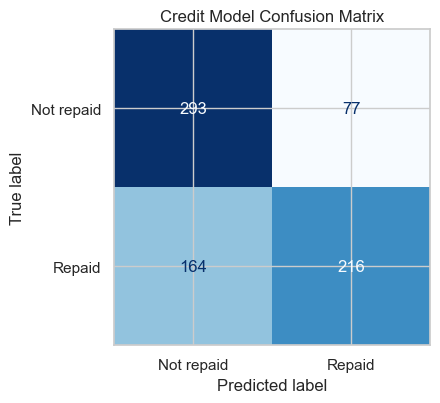

,metric,value
0,accuracy,0.678667
1,auc,0.739893
2,approval_threshold,0.550000


In [4]:

y_score = model.predict_proba(X_test)[:, 1]
y_pred = (y_score >= APPROVAL_THRESHOLD).astype(int)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_score)
cm = confusion_matrix(y_test, y_pred)

performance_table = pd.DataFrame({
    'metric': ['accuracy', 'auc', 'approval_threshold'],
    'value': [accuracy, auc, APPROVAL_THRESHOLD]
})
performance_table.to_csv(OUTPUT_DIR / 'model_performance_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ConfusionMatrixDisplay(cm, display_labels=['Not repaid', 'Repaid']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Credit Model Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=180)
plt.show()

performance_table


## 4. Fairness metrics: approval disparity, FPR gap, FNR gap

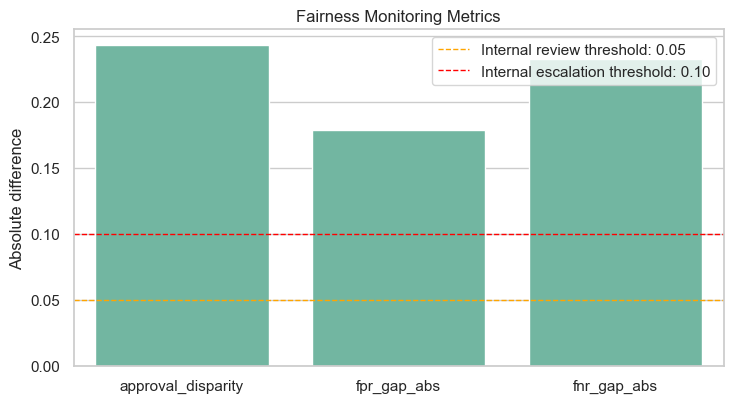

,approval_rate_majority,approval_rate_minority,approval_disparity,fpr_majority,fpr_minority,fpr_gap_abs,fnr_majority,fnr_minority,fnr_gap_abs
0,0.484421,0.241552,0.242869,0.308192,0.12931,0.178882,0.370172,0.602985,0.232813


In [5]:

def group_rates(df, group_col='protected_group'):
    rows = []
    for group, g in df.groupby(group_col):
        approved = g['approved']
        actual = g['actual_repaid']
        fp = ((approved == 1) & (actual == 0)).sum()
        tn = ((approved == 0) & (actual == 0)).sum()
        fn = ((approved == 0) & (actual == 1)).sum()
        tp = ((approved == 1) & (actual == 1)).sum()
        rows.append({
            group_col: group,
            'n': len(g),
            'approval_rate': approved.mean(),
            'fpr': fp / (fp + tn) if (fp + tn) else np.nan,
            'fnr': fn / (fn + tp) if (fn + tp) else np.nan,
            'accuracy': (tp + tn) / len(g),
        })
    return pd.DataFrame(rows)


def fairness_metrics(df):
    rates = group_rates(df)
    majority = rates.loc[rates['protected_group'] == 'Majority'].iloc[0]
    minority = rates.loc[rates['protected_group'] == 'Minority'].iloc[0]
    return pd.DataFrame([{
        'approval_rate_majority': majority['approval_rate'],
        'approval_rate_minority': minority['approval_rate'],
        'approval_disparity': majority['approval_rate'] - minority['approval_rate'],
        'fpr_majority': majority['fpr'],
        'fpr_minority': minority['fpr'],
        'fpr_gap_abs': abs(majority['fpr'] - minority['fpr']),
        'fnr_majority': majority['fnr'],
        'fnr_minority': minority['fnr'],
        'fnr_gap_abs': abs(majority['fnr'] - minority['fnr']),
    }])

fairness_table = fairness_metrics(loan_df)
group_rate_table = group_rates(loan_df)
fairness_table.to_csv(OUTPUT_DIR / 'fairness_metrics_summary.csv', index=False)
group_rate_table.to_csv(OUTPUT_DIR / 'fairness_group_rates.csv', index=False)

plot_df = fairness_table.melt(var_name='metric', value_name='value')
plot_df = plot_df[plot_df['metric'].isin(['approval_disparity', 'fpr_gap_abs', 'fnr_gap_abs'])]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(data=plot_df, x='metric', y='value', ax=ax)
ax.axhline(0.05, color='orange', linestyle='--', linewidth=1, label='Internal review threshold: 0.05')
ax.axhline(0.10, color='red', linestyle='--', linewidth=1, label='Internal escalation threshold: 0.10')
ax.set_title('Fairness Monitoring Metrics')
ax.set_xlabel('')
ax.set_ylabel('Absolute difference')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fairness_metrics.png', dpi=180)
plt.show()

fairness_table


## 5. Explainability: feature importance and rejection reasons

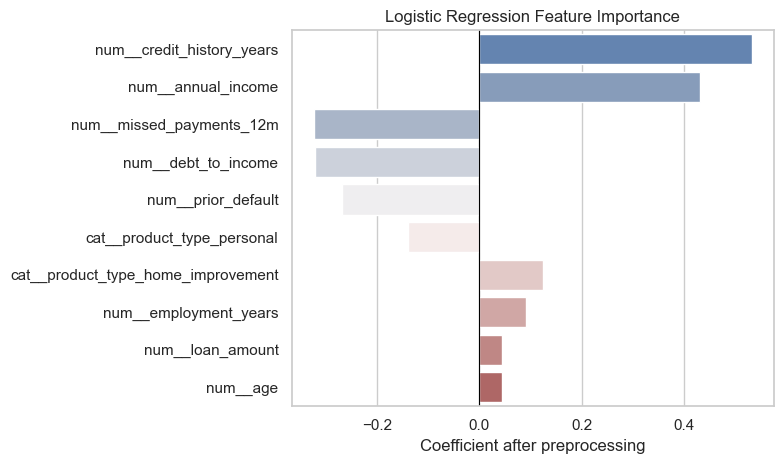

,feature,coefficient,absolute_importance
4,num__credit_history_years,0.533336,0.533336
1,num__annual_income,0.432133,0.432133
5,num__missed_payments_12m,-0.324508,0.324508
3,num__debt_to_income,-0.321480,0.321480
6,num__prior_default,-0.268388,0.268388
9,cat__product_type_personal,-0.139483,0.139483
8,cat__product_type_home_improvement,0.123959,0.123959
2,num__employment_years,0.090146,0.090146
7,num__loan_amount,0.044038,0.044038
0,num__age,0.043364,0.043364


In [6]:

encoded_feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefs = model.named_steps['classifier'].coef_[0]
feature_importance = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': coefs,
    'absolute_importance': np.abs(coefs)
}).sort_values('absolute_importance', ascending=False)
feature_importance.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.8))
top_features = feature_importance.head(10).copy()
sns.barplot(data=top_features, y='feature', x='coefficient', ax=ax, palette='vlag')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Feature Importance')
ax.set_xlabel('Coefficient after preprocessing')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=180)
plt.show()

feature_importance.head(10)


In [7]:

def rejection_reasons(row, max_reasons=3):
    reasons = []
    if row['debt_to_income'] > 0.42:
        reasons.append('High debt-to-income ratio')
    if row['missed_payments_12m'] >= 2:
        reasons.append('Recent missed payments')
    if row['credit_history_years'] < 4:
        reasons.append('Limited credit history')
    if row['prior_default'] == 1:
        reasons.append('Prior default indicator')
    if row['loan_amount'] / max(row['annual_income'], 1) > 0.55:
        reasons.append('Requested loan amount is high relative to income')
    if row['employment_years'] < 1.5:
        reasons.append('Short employment history')
    return '; '.join(reasons[:max_reasons]) if reasons else 'Model score below approval threshold; no single dominant rule-based reason'

rejected = loan_df[loan_df['approved'] == 0].copy()
rejected['rejection_reasons'] = rejected.apply(rejection_reasons, axis=1)
rejection_sample = rejected[[
    'applicant_id', 'jurisdiction', 'protected_group', 'predicted_repayment_probability',
    'approved', 'rejection_reasons'
]].head(20)
rejection_sample.to_csv(OUTPUT_DIR / 'rejection_reasons_sample.csv', index=False)
rejection_sample


,applicant_id,jurisdiction,protected_group,predicted_repayment_probability,approved,rejection_reasons
0,A00-00000,US,Minority,0.111725,0,High debt-to-income ratio; Recent missed payme...
1,A00-00001,EU,Majority,0.457388,0,Model score below approval threshold; no singl...
2,A00-00002,EU,Minority,0.263029,0,Prior default indicator
3,A00-00003,EU,Minority,0.511841,0,High debt-to-income ratio; Recent missed payments
4,A00-00004,US,Majority,0.407549,0,Model score below approval threshold; no singl...
5,A00-00005,US,Minority,0.293755,0,High debt-to-income ratio
6,A00-00006,EU,Minority,0.272502,0,Recent missed payments
8,A00-00008,US,Majority,0.445228,0,High debt-to-income ratio; Recent missed payments
9,A00-00009,EU,Majority,0.135942,0,Limited credit history; Prior default indicator
11,A00-00011,US,Minority,0.402037,0,Recent missed payments


## 6. Monitoring period and model drift detection

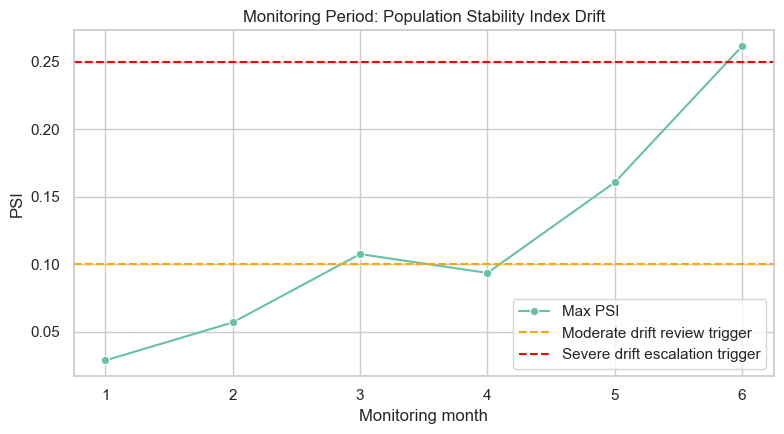

,month,n_applications,accuracy,auc,approval_rate,score_psi,income_psi,debt_to_income_psi,max_psi,drift_flag,approval_rate_majority,approval_rate_minority,approval_disparity,fpr_majority,fpr_minority,fpr_gap_abs,fnr_majority,fnr_minority,fnr_gap_abs
0,1,900,0.651111,0.720438,0.366667,0.021193,0.028771,0.013815,0.028771,False,0.456198,0.183051,0.273147,0.303136,0.091429,0.211707,0.405660,0.683333,0.277673
1,2,900,0.627778,0.708308,0.338889,0.056906,0.020080,0.025359,0.056906,False,0.419835,0.172881,0.246953,0.296667,0.120879,0.175788,0.459016,0.743363,0.284346
2,3,900,0.696667,0.752850,0.331111,0.107506,0.033662,0.058320,0.107506,True,0.401274,0.169118,0.232156,0.250746,0.064516,0.186230,0.426621,0.604651,0.178030
3,4,900,0.668889,0.722952,0.317778,0.078814,0.037555,0.093557,0.093557,False,0.375610,0.192982,0.182627,0.213622,0.125714,0.087908,0.445205,0.700000,0.254795
4,5,900,0.692222,0.752705,0.264444,0.160608,0.044736,0.152182,0.160608,True,0.327948,0.124555,0.203393,0.178363,0.054054,0.124309,0.487365,0.739583,0.252219
5,6,900,0.652222,0.709288,0.238889,0.232747,0.135083,0.261437,0.261437,True,0.304493,0.107023,0.197469,0.189873,0.080952,0.108921,0.568421,0.831461,0.263040


In [8]:

def psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    quantiles = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        quantiles = np.linspace(expected.min(), expected.max(), bins + 1)
    expected_counts, _ = np.histogram(expected, bins=quantiles)
    actual_counts, _ = np.histogram(actual, bins=quantiles)
    expected_pct = np.clip(expected_counts / max(expected_counts.sum(), 1), 1e-6, None)
    actual_pct = np.clip(actual_counts / max(actual_counts.sum(), 1), 1e-6, None)
    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))

baseline_scores = loan_df['predicted_repayment_probability']
monitoring_rows = []
for month in range(1, 7):
    month_df = generate_loan_applicants(n=900, seed=RANDOM_SEED, drift_month=month)
    month_df['predicted_repayment_probability'] = model.predict_proba(month_df[feature_cols])[:, 1]
    month_df['approved'] = (month_df['predicted_repayment_probability'] >= APPROVAL_THRESHOLD).astype(int)
    score_psi = psi(baseline_scores, month_df['predicted_repayment_probability'])
    income_psi = psi(loan_df['annual_income'], month_df['annual_income'])
    debt_psi = psi(loan_df['debt_to_income'], month_df['debt_to_income'])
    fm = fairness_metrics(month_df).iloc[0].to_dict()
    monitoring_rows.append({
        'month': month,
        'n_applications': len(month_df),
        'accuracy': accuracy_score(month_df['actual_repaid'], month_df['approved']),
        'auc': roc_auc_score(month_df['actual_repaid'], month_df['predicted_repayment_probability']),
        'approval_rate': month_df['approved'].mean(),
        'score_psi': score_psi,
        'income_psi': income_psi,
        'debt_to_income_psi': debt_psi,
        'max_psi': max(score_psi, income_psi, debt_psi),
        'drift_flag': max(score_psi, income_psi, debt_psi) >= 0.10,
        **fm
    })

monitoring_results = pd.DataFrame(monitoring_rows)
monitoring_results.to_csv(OUTPUT_DIR / 'monitoring_results.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=monitoring_results, x='month', y='max_psi', marker='o', ax=ax, label='Max PSI')
ax.axhline(0.10, color='orange', linestyle='--', label='Moderate drift review trigger')
ax.axhline(0.25, color='red', linestyle='--', label='Severe drift escalation trigger')
ax.set_title('Monitoring Period: Population Stability Index Drift')
ax.set_ylabel('PSI')
ax.set_xlabel('Monitoring month')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'drift_monitoring.png', dpi=180)
plt.show()

monitoring_results


## 7. Jurisdiction rule engine: US vs EU

In [9]:

RULES = {
    'US': {
        'regulatory_focus': 'Fair lending, anti-discrimination, and adverse action explanations',
        'legal_sources': 'ECOA; Regulation B; CFPB Circulars 2022-03 and 2023-03',
        'approval_disparity_threshold': 0.10,
        'fpr_gap_threshold': 0.05,
        'fnr_gap_threshold': 0.05,
        'drift_threshold': 0.30,
        'requires_adverse_action_reasons': True,
        'requires_human_oversight_workflow': False,
        'requires_high_risk_ai_documentation': False,
    },
    'EU': {
        'regulatory_focus': 'High-risk AI governance, lifecycle risk management, transparency, and human oversight',
        'legal_sources': 'Regulation (EU) 2024/1689, including Annex III and Articles 8-15; post-market monitoring obligations',
        'approval_disparity_threshold': 0.07,
        'fpr_gap_threshold': 0.04,
        'fnr_gap_threshold': 0.04,
        'drift_threshold': 0.10,
        'requires_adverse_action_reasons': False,
        'requires_human_oversight_workflow': True,
        'requires_high_risk_ai_documentation': True,
    }
}

pd.DataFrame(RULES).T


,regulatory_focus,legal_sources,approval_disparity_threshold,fpr_gap_threshold,fnr_gap_threshold,drift_threshold,requires_adverse_action_reasons,requires_human_oversight_workflow,requires_high_risk_ai_documentation
US,"Fair lending, anti-discrimination, and adverse...",ECOA; Regulation B; CFPB Circulars 2022-03 and...,0.1,0.05,0.05,0.3,True,False,False
EU,"High-risk AI governance, lifecycle risk manage...","Regulation (EU) 2024/1689, including Annex III...",0.07,0.04,0.04,0.1,False,True,True


## 8. Compliance report: same metric, different jurisdictional result

In [10]:

def evaluate_jurisdiction(metrics_row, jurisdiction):
    rules = RULES[jurisdiction]
    checks = {
        'approval_disparity_breach': metrics_row['approval_disparity'] >= rules['approval_disparity_threshold'],
        'fpr_gap_breach': metrics_row['fpr_gap_abs'] >= rules['fpr_gap_threshold'],
        'fnr_gap_breach': metrics_row['fnr_gap_abs'] >= rules['fnr_gap_threshold'],
        'drift_breach': metrics_row['max_psi'] >= rules['drift_threshold'],
    }
    triggered = [name for name, value in checks.items() if value]
    if jurisdiction == 'US':
        consequence = []
        if any(checks[k] for k in ['approval_disparity_breach', 'fpr_gap_breach', 'fnr_gap_breach']):
            consequence.append('Fair lending review / disparate impact investigation')
        if rules['requires_adverse_action_reasons']:
            consequence.append('Validate specific and accurate adverse action reasons for rejected applicants')
        if checks['drift_breach']:
            consequence.append('Model risk review because severe drift may undermine fair lending controls')
    else:
        consequence = []
        if any(checks.values()):
            consequence.append('High-risk AI risk-management update and mitigation plan')
        if rules['requires_human_oversight_workflow']:
            consequence.append('Human oversight escalation and documented review')
        if rules['requires_high_risk_ai_documentation']:
            consequence.append('Update technical documentation, monitoring logs, and governance record')
    status = 'Escalate' if triggered else 'Pass with monitoring'
    return status, '; '.join(triggered) if triggered else 'none', '; '.join(consequence)

latest = monitoring_results.iloc[-1].to_dict()
base_metrics = fairness_table.iloc[0].to_dict()
base_metrics.update({'max_psi': latest['max_psi']})

report_rows = []
for jurisdiction in ['US', 'EU']:
    status, triggered, consequence = evaluate_jurisdiction(base_metrics, jurisdiction)
    report_rows.append({
        'jurisdiction': jurisdiction,
        'regulatory_focus': RULES[jurisdiction]['regulatory_focus'],
        'legal_sources': RULES[jurisdiction]['legal_sources'],
        'approval_disparity': base_metrics['approval_disparity'],
        'approval_disparity_threshold': RULES[jurisdiction]['approval_disparity_threshold'],
        'fpr_gap_abs': base_metrics['fpr_gap_abs'],
        'fpr_gap_threshold': RULES[jurisdiction]['fpr_gap_threshold'],
        'fnr_gap_abs': base_metrics['fnr_gap_abs'],
        'fnr_gap_threshold': RULES[jurisdiction]['fnr_gap_threshold'],
        'latest_monitoring_max_psi': base_metrics['max_psi'],
        'drift_threshold': RULES[jurisdiction]['drift_threshold'],
        'status': status,
        'triggered_controls': triggered,
        'required_governance_response': consequence,
        'important_limitations': 'Prototype uses synthetic data and internal governance thresholds; it does not automate final legal interpretation or replace compliance/legal review.'
    })

jurisdiction_compliance_report = pd.DataFrame(report_rows)
jurisdiction_compliance_report.to_csv(OUTPUT_DIR / 'jurisdiction_compliance_report.csv', index=False)
jurisdiction_compliance_report


,jurisdiction,regulatory_focus,legal_sources,approval_disparity,approval_disparity_threshold,fpr_gap_abs,fpr_gap_threshold,fnr_gap_abs,fnr_gap_threshold,latest_monitoring_max_psi,drift_threshold,status,triggered_controls,required_governance_response,important_limitations
0,US,"Fair lending, anti-discrimination, and adverse...",ECOA; Regulation B; CFPB Circulars 2022-03 and...,0.242869,0.10,0.178882,0.05,0.232813,0.05,0.261437,0.3,Escalate,approval_disparity_breach; fpr_gap_breach; fnr...,Fair lending review / disparate impact investi...,Prototype uses synthetic data and internal gov...
1,EU,"High-risk AI governance, lifecycle risk manage...","Regulation (EU) 2024/1689, including Annex III...",0.242869,0.07,0.178882,0.04,0.232813,0.04,0.261437,0.1,Escalate,approval_disparity_breach; fpr_gap_breach; fnr...,High-risk AI risk-management update and mitiga...,Prototype uses synthetic data and internal gov...


## 9. Export result tables and charts for PPT

In [11]:

export_manifest = pd.DataFrame({
    'file': [
        'Task3_demo.ipynb',
        'synthetic_loan_data.csv',
        'monitoring_results.csv',
        'jurisdiction_compliance_report.csv',
        'model_performance_summary.csv',
        'fairness_metrics_summary.csv',
        'fairness_group_rates.csv',
        'feature_importance.csv',
        'rejection_reasons_sample.csv',
        'confusion_matrix.png',
        'fairness_metrics.png',
        'feature_importance.png',
        'drift_monitoring.png',
    ],
    'ppt_use': [
        'Main reproducible prototype notebook',
        'Synthetic lending data table',
        'Monitoring and drift table',
        'US/EU compliance comparison table',
        'Model performance table',
        'Fairness metric table',
        'Group-level approval/FPR/FNR rates',
        'Explainability table',
        'Example adverse-action style rejection reasons',
        'Model performance chart',
        'Fairness chart',
        'Explainability chart',
        'Drift monitoring chart',
    ]
})
export_manifest.to_csv(OUTPUT_DIR / 'task3_export_manifest.csv', index=False)
export_manifest


,file,ppt_use
0,Task3_demo.ipynb,Main reproducible prototype notebook
1,synthetic_loan_data.csv,Synthetic lending data table
2,monitoring_results.csv,Monitoring and drift table
3,jurisdiction_compliance_report.csv,US/EU compliance comparison table
4,model_performance_summary.csv,Model performance table
5,fairness_metrics_summary.csv,Fairness metric table
6,fairness_group_rates.csv,Group-level approval/FPR/FNR rates
7,feature_importance.csv,Explainability table
8,rejection_reasons_sample.csv,Example adverse-action style rejection reasons
9,confusion_matrix.png,Model performance chart
